In [1]:
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
%load_ext autoreload
%autoreload 2

In [2]:
repo_root = Path.cwd().resolve()
for candidate in [repo_root, repo_root.parent]:
    if (candidate / "data").exists():
        data_dir = candidate / "data"
        break
else:
    raise FileNotFoundError("Unable to find the 'data' directory. Set the working directory to the yeast repo root.")


confident = data_dir / "summary_confidences.parquet"
confident = pl.scan_parquet(str(confident))

pairs = data_dir / "summary_pairs.parquet"
pairs = pl.scan_parquet(str(pairs))

In [3]:
pairs.collect().head()

pair_ids,name,batch_id,pool_id,chain_pair_iptm_best,chain_pair_iptm_mean,af3_pair,af3_id1,af3_id2,seq_len1,seq_len2,pair_len,chain_pair_iptm_best_corrected,chain_pair_iptm_mean_corrected,af3_pair_score,michaelis2023:name,michaelis2023:source,michaelis2023:Source Gene names (SGD/UniProt-primary or ordered locus),michaelis2023:target,michaelis2023:Target Gene names (SGD/UniProt-primary or ordered locus),michaelis2023:score_FDR+cor,michaelis2023:score_FDR,michaelis2023:score_cor,michaelis2023:F_FDR_0.05,michaelis2023:F_FDR_0.01,michaelis2023:F_FDR_0.001,michaelis2023:F_FDR_1e-04,michaelis2023:R_FDR_0.05,michaelis2023:R_FDR_0.01,michaelis2023:R_FDR_0.001,michaelis2023:R_FDR_1e-04,michaelis2023:cor_val_[std_dev],michaelis2023:cor_val_>=4_[std_dev],michaelis2023:cor_val_>=5_[std_dev],michaelis2023:Inter-cluster edge,michaelis2023:Count of publications,michaelis2023:Pubmed Ids,…,biogrid:Entrez Gene Interactor B,biogrid:BioGRID ID Interactor A,biogrid:BioGRID ID Interactor B,biogrid:Systematic Name Interactor A,biogrid:Systematic Name Interactor B,biogrid:Official Symbol Interactor A,biogrid:Official Symbol Interactor B,biogrid:Synonyms Interactor A,biogrid:Synonyms Interactor B,biogrid:Experimental System,biogrid:Experimental System Type,biogrid:Author,biogrid:Publication Source,biogrid:Organism ID Interactor A,biogrid:Organism ID Interactor B,biogrid:Throughput,biogrid:Score,biogrid:Modification,biogrid:Qualifications,biogrid:Tags,biogrid:Source Database,biogrid:SWISS-PROT Accessions Interactor A,biogrid:TREMBL Accessions Interactor A,biogrid:REFSEQ Accessions Interactor A,biogrid:SWISS-PROT Accessions Interactor B,biogrid:TREMBL Accessions Interactor B,biogrid:REFSEQ Accessions Interactor B,biogrid:Ontology Term IDs,biogrid:Ontology Term Names,biogrid:Ontology Term Categories,biogrid:Ontology Term Qualifier IDs,biogrid:Ontology Term Qualifier Names,biogrid:Ontology Term Types,biogrid:Organism Name Interactor A,biogrid:Organism Name Interactor B,biogrid:af3_id1,biogrid:af3_id2
list[str],str,str,str,f64,f64,str,str,str,i64,i64,i64,f64,f64,i64,str,str,str,str,str,f64,f64,f64,bool,bool,bool,bool,bool,bool,bool,bool,f64,bool,bool,bool,f64,str,…,str,f64,f64,str,str,str,str,str,str,str,str,str,str,f64,f64,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"[""p32528"", ""p39985""]","""000043c11bb7cccdb7632f3ee98ea1…","""26.03/euler-std-rtx_pro_6000-r…","""p32528_p39985_p53107_q02648_q0…",0.2,0.2,"""p32528_p39985""","""p32528""","""p39985""",1835,1022,2857,0.000663,0.000344,176,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"[""p32528"", ""p53107""]","""000043c11bb7cccdb7632f3ee98ea1…","""26.03/euler-std-rtx_pro_6000-r…","""p32528_p39985_p53107_q02648_q0…",0.18,0.18,"""p32528_p53107""","""p32528""","""p53107""",1835,440,2275,0.006406,0.006103,689,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"[""p32528"", ""q02648""]","""000043c11bb7cccdb7632f3ee98ea1…","""26.03/euler-std-rtx_pro_6000-r…","""p32528_p39985_p53107_q02648_q0…",0.18,0.18,"""p32528_q02648""","""p32528""","""q02648""",1835,567,2402,0.000531,0.000224,168,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"[""p32528"", ""q03533""]","""000043c11bb7cccdb7632f3ee98ea1…","""26.03/euler-std-rtx_pro_6000-r…","""p32528

In [4]:
confident.collect().head()

name,seed,sample,ranking_score,fraction_disordered,has_clash,iptm,ptm,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,summary_confidences_path,predictions_path
str,i64,i64,f64,f64,f64,f64,f64,list[f64],list[list[f64]],list[list[f64]],list[f64],str,str
"""00057fce464a9de2ec699af7e72164…",4,0,0.326816,0.02,0.0,0.3,0.39,"[0.1, 0.18, … 0.13]","[[0.16, 0.17, … 0.11], [0.17, 0.35, … 0.21], … [0.11, 0.21, … 0.65]]","[[0.76, 29.74, … 31.4], [29.74, 0.76, … 27.18], … [30.8, 27.5, … 0.76]]","[0.16, 0.35, … 0.65]","""00057fce464a9de2ec699af7e72164…","""/cluster/project/beltrao/jjaen…"
"""00057fce464a9de2ec699af7e72164…",4,1,0.320315,0.02,0.0,0.29,0.39,"[0.1, 0.18, … 0.13]","[[0.16, 0.17, … 0.11], [0.17, 0.35, … 0.2], … [0.11, 0.2, … 0.65]]","[[0.76, 30.09, … 31.11], [29.66, 0.76, … 28.79], … [30.88, 29.34, … 0.76]]","[0.16, 0.35, … 0.65]","""00057fce464a9de2ec699af7e72164…","""/cluster/project/beltrao/jjaen…"
"""00057fce464a9de2ec699af7e72164…",4,2,0.32585,0.03,0.0,0.29,0.4,"[0.09, 0.18, … 0.12]","[[0.15, 0.18, … 0.11], [0.18, 0.35, … 0.19], … [0.11, 0.19, … 0.65]]","[[0.76, 28.59, … 30.76], [29.38, 0.76, … 30.81], … [30.49, 30.56, … 0.76]]","[0.15, 0.35, … 0.65]","""00057fce464a9de2ec699af7e72164…","""/cluster/project/beltrao/jjaen…"
"""00057fce464a9de2ec699af7e72164…",4,3,0.324487,0.01,0.0,0.3,0.39,"[0.09, 0.18, … 0.13]","[[0.17, 0.18, … 0.11], [0.18, 0.35, … 0.2], … [0.11, 0.2, … 0.65]]","[[0.76, 30.21, … 31.02], [29.93, 0.76, … 28.63], … [31.01, 29.77, … 0.76]]","[0.17, 0.35, … 0.65]","""00057fce464a9de2ec699af7e72164…","""/cluster/project/beltrao/jjaen…"
"""00057fce464a9de2ec699af7e72164…",4,4,0.341085,0.04,0.0,0.3,0.39,"[0.1, 0.18, … 0.13]","[[0.16, 0.18, … 0.11], [0.18, 0.35, … 0.19], … [0.11, 0.19, … 0.65]]","[[0.76, 28.02, … 30.91], [28.69, 0.76, … 29.28], … [30.45, 29.97, … 0.76]]","[0.16, 0.35, … 0.65]","""00057fce464a9de2ec699af7e72164…","""/cluster/project/beltrao/jjaen…"


In [ ]:
sizeCoreceted = (pairs.collect())["chain_pair_iptm_mean_corrected"]

sizeCoreceted.describe()


statistic,value
str,f64
"""count""",7.631089e6
"""null_count""",0.0
"""mean""",0.007741
"""std""",0.019879
"""min""",-0.006037
"""25%""",0.001281
"""50%""",0.003861
"""75%""",0.007415
"""max""",0.796704


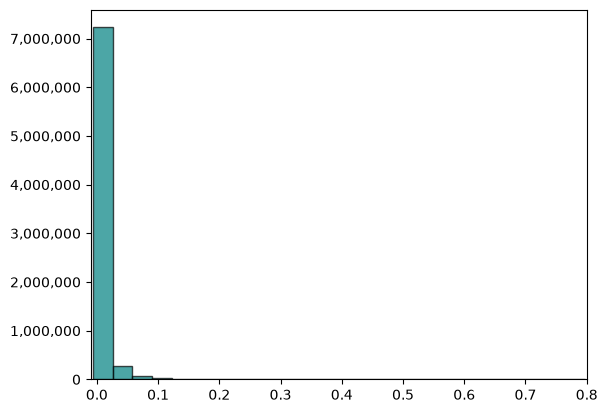

In [6]:
#Histogram
fig, ax = plt.subplots()
plt.hist(sizeCoreceted, bins=25, color='teal', edgecolor='black', alpha=0.7)
ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.xlim(-0.01, 0.8)
# Display the plot
plt.show()

In [3]:
threshold = 0.55
chunk_size = 500000 


pairs['z_score'] = stats.zscore(pairs.collect())["chain_pair_iptm_mean_corrected"]

: 

In [10]:
cutoff_99 = np.percentile((pairs.collect())["chain_pair_iptm_mean_corrected"], 99.9)

In [11]:
# Filter top 1% 
top_edges = pairs.filter(pl.col("chain_pair_iptm_mean_corrected") >= cutoff_99)
# top_edges.to_csv("top_1_percent_edges.csv", index=False)
print(len(top_edges.collect()))
print(top_edges.collect().head())

7632
shape: (5, 105)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ pair_ids  ┆ name      ┆ batch_id  ┆ pool_id   ┆ … ┆ biogrid:O ┆ biogrid:O ┆ biogrid:a ┆ biogrid: │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ rganism   ┆ rganism   ┆ f3_id1    ┆ af3_id2  │
│ list[str] ┆ str       ┆ str       ┆ str       ┆   ┆ Name      ┆ Name      ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ Interact… ┆ Interact… ┆ str       ┆ str      │
│           ┆           ┆           ┆           ┆   ┆ ---       ┆ ---       ┆           ┆          │
│           ┆           ┆           ┆           ┆   ┆ str       ┆ str       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ ["p10862" ┆ 00068ac4f ┆ 26.03/eul ┆ p10862_p1 ┆ … ┆ null      ┆ null      ┆ null      ┆ null     │
│ ,         ┆ ad26c71bc ┆ er-std-rt ┆ 5731_p191 ┆   ┆           ┆     

In [13]:
# Can we threshold the corrected iPTM scores? The authors recommended that. What does the distribution of corrected scores look like and is there an obvious cutoff?
# If we apply a threshold, we can avoid dealing with negative scores and the scores will be more SPRAS compatible.
# We can have small magnitude values
(top_edges.collect())["chain_pair_iptm_mean_corrected"].describe()

statistic,value
str,f64
"""count""",7632.0
"""null_count""",0.0
"""mean""",0.371742
"""std""",0.104582
"""min""",0.262453
"""25%""",0.292304
"""50%""",0.337522
"""75%""",0.419124
"""max""",0.796704
